In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [3]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

In [4]:
model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
train_losses = []
train_acc = []
val_losses = []
val_acc = []

epochs = 5

for epoch in range(epochs):

    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    train_losses.append(train_loss)
    train_acc.append(train_accuracy)
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(test_loader)
    val_accuracy = val_correct / val_total

    val_losses.append(val_loss)
    val_acc.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_accuracy:.4f}")
    print("-" * 40)

Epoch [1/5]
Train Loss: 0.0118 | Train Acc: 0.9958
Val Loss:   0.0237 | Val Acc:   0.9932
----------------------------------------
Epoch [2/5]
Train Loss: 0.0113 | Train Acc: 0.9963
Val Loss:   0.0307 | Val Acc:   0.9925
----------------------------------------
Epoch [3/5]
Train Loss: 0.0089 | Train Acc: 0.9969
Val Loss:   0.0318 | Val Acc:   0.9922
----------------------------------------
Epoch [4/5]
Train Loss: 0.0110 | Train Acc: 0.9964
Val Loss:   0.0285 | Val Acc:   0.9934
----------------------------------------
Epoch [5/5]
Train Loss: 0.0098 | Train Acc: 0.9967
Val Loss:   0.0332 | Val Acc:   0.9924
----------------------------------------


In [12]:
model.eval()

test_loss = 0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_loss = test_loss / len(test_loader)
test_accuracy = test_correct / test_total

print("FINAL TEST RESULTS")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

FINAL TEST RESULTS
Test Loss: 0.0332
Test Accuracy: 0.9924


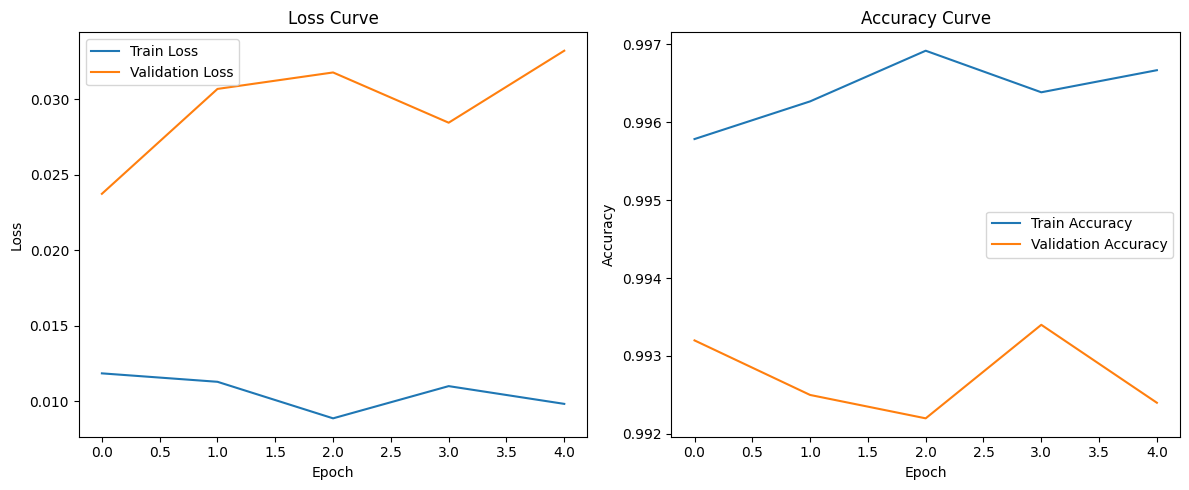

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
train_losses = []
train_acc = []
val_losses = []
val_acc = []

model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

epochs = 5

for epoch in range(epochs):

    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    train_losses.append(train_loss)
    train_acc.append(train_accuracy)

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(test_loader)
    val_accuracy = val_correct / val_total

    val_losses.append(val_loss)
    val_acc.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_accuracy:.4f}")
    print("-" * 40)

Epoch [1/5]
Train Loss: 0.1660 | Train Acc: 0.9477
Val Loss:   0.0463 | Val Acc:   0.9852
----------------------------------------
Epoch [2/5]
Train Loss: 0.0677 | Train Acc: 0.9789
Val Loss:   0.0346 | Val Acc:   0.9902
----------------------------------------
Epoch [3/5]
Train Loss: 0.0523 | Train Acc: 0.9841
Val Loss:   0.0390 | Val Acc:   0.9879
----------------------------------------
Epoch [4/5]
Train Loss: 0.0430 | Train Acc: 0.9868
Val Loss:   0.0316 | Val Acc:   0.9896
----------------------------------------
Epoch [5/5]
Train Loss: 0.0366 | Train Acc: 0.9885
Val Loss:   0.0237 | Val Acc:   0.9924
----------------------------------------


In [15]:
model.eval()

test_loss = 0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_loss = test_loss / len(test_loader)
test_accuracy = test_correct / test_total

print("SGD FINAL TEST RESULTS")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

SGD FINAL TEST RESULTS
Test Loss: 0.0237
Test Accuracy: 0.9924


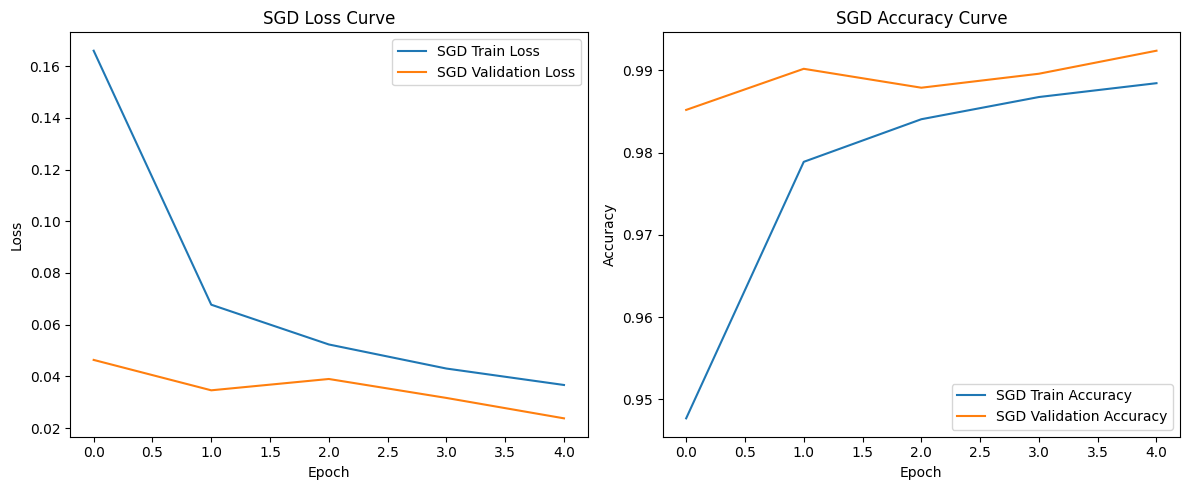

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="SGD Train Loss")
plt.plot(val_losses, label="SGD Validation Loss")
plt.title("SGD Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc, label="SGD Train Accuracy")
plt.plot(val_acc, label="SGD Validation Accuracy")
plt.title("SGD Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
print("=== FINAL COMPARISON ===")

print("Model 1:")
print(f"Test Loss: 0.0237")
print(f"Test Accuracy: 0.9924")

print("-" * 30)

print("Model 2:")
print(f"Test Loss: 0.0332")
print(f"Test Accuracy: 0.9924")

=== FINAL COMPARISON ===
Model 1:
Test Loss: 0.0237
Test Accuracy: 0.9924
------------------------------
Model 2:
Test Loss: 0.0332
Test Accuracy: 0.9924
